# HCP individual behavioral prediction


In [14]:
from pathlib import Path
import sys
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests


# Resolve all inputs relative to analysis/behavior.
project_root = Path('../..').resolve()
rsi_path = project_root / 'results/rsi/HCP/test_multibin_rsi.npy'
test_ids_path = project_root / 'data/HCP/info/test.txt'
hcp_info_path = project_root / 'data/HCP/info/hcp_998.csv'

result_dir = project_root / 'analysis/behavior/results'
result_dir.mkdir(parents=True, exist_ok=True)

# Import the reusable nested-CV and permutation helpers.
if str(project_root) not in sys.path:
    # Keep installed packages ahead of repository-only analysis helpers.
    sys.path.append(str(project_root))
from analysis.behavior.regression import (
    alphas, permutation_test, regression_nested_cv,
)


## Behavioral phenotypes

In [15]:
alertness = ['MMSE_Score', 'PSQI_Score']

cognition = [
    'PicSeq_Unadj', 'CardSort_Unadj', 'Flanker_Unadj', 'PMAT24_A_CR',
    'ReadEng_Unadj', 'PicVocab_Unadj', 'ProcSpeed_Unadj', 'DDisc_AUC_40K',
    'VSPLOT_TC', 'SCPT_SEN', 'SCPT_SPEC', 'IWRD_TOT', 'ListSort_Unadj',
    'CogCrystalComp_Unadj', 'CogTotalComp_Unadj', 'CogFluidComp_Unadj',
]

emotion_recognition = ['ER40_CR', 'ER40ANG', 'ER40FEAR', 'ER40HAP', 'ER40NOE', 'ER40SAD']
negative_affect = [
    'AngAffect_Unadj', 'AngHostil_Unadj', 'AngAggr_Unadj',
    'FearAffect_Unadj', 'FearSomat_Unadj', 'Sadness_Unadj',
]
psychological_well_being = ['LifeSatisf_Unadj', 'MeanPurp_Unadj', 'PosAffect_Unadj']
social_relationships = [
    'Friendship_Unadj', 'Loneliness_Unadj', 'PercHostil_Unadj',
    'PercReject_Unadj', 'EmotSupp_Unadj', 'InstruSupp_Unadj',
]
stress_self_efficacy = ['PercStress_Unadj', 'SelfEff_Unadj']
emotion = (
    emotion_recognition + negative_affect + psychological_well_being
    + social_relationships + stress_self_efficacy
)

motor = ['Endurance_Unadj', 'GaitSpeed_Comp', 'Dexterity_Unadj', 'Strength_Unadj']
personality = ['NEOFAC_A', 'NEOFAC_O', 'NEOFAC_C', 'NEOFAC_N', 'NEOFAC_E']
sensory = ['Odor_Unadj', 'PainIntens_RawScore', 'Taste_Unadj', 'Mars_Final']
task_performance = [
    'Emotion_Task_Face_Acc', 'Language_Task_Math_Avg_Difficulty_Level',
    'Language_Task_Story_Avg_Difficulty_Level', 'Relational_Task_Acc',
    'Social_Task_Perc_Random', 'Social_Task_Perc_TOM', 'WM_Task_Acc',
]

behaviors = (
    personality + motor + sensory + emotion + task_performance
    + alertness + cognition
)
print(f'Behavioral phenotypes: {len(behaviors)}')


Behavioral phenotypes: 61


## Load and align the current RISE data

In [16]:
test_subject_ids = pd.read_csv(test_ids_path, header=None, dtype=str)[0].tolist()
rsi_multibin = np.load(rsi_path)

if rsi_multibin.ndim != 3:
    raise ValueError(f'Expected a 3D multibin RSI array, got shape {rsi_multibin.shape}')
if rsi_multibin.shape[0] != len(test_subject_ids):
    raise ValueError(
        f'RSI subjects ({rsi_multibin.shape[0]}) do not match test IDs '
        f'({len(test_subject_ids)}).'
    )
if not np.isfinite(rsi_multibin).all():
    raise ValueError('The multibin RSI array contains NaN or infinite values.')

hcp_info = pd.read_csv(hcp_info_path, dtype={'Subject': str}).set_index('Subject')
missing_subjects = sorted(set(test_subject_ids) - set(hcp_info.index))
if missing_subjects:
    raise ValueError(f'{len(missing_subjects)} test subjects are absent from hcp_998.csv.')

missing_columns = sorted(set(behaviors + ['Age_in_Yrs', 'Gender']) - set(hcp_info.columns))
if missing_columns:
    raise ValueError(f'Missing HCP columns: {missing_columns}')

# Preserve the subject order defined by data/HCP/info/test.txt, which is also the
# first-axis order used by test_multibin_rsi.npy.
hcp_test = hcp_info.loc[test_subject_ids].copy()
x = rsi_multibin.reshape(rsi_multibin.shape[0], -1)

print(f'Subjects: {len(test_subject_ids)}')
print(f'Multibin RSI: {rsi_multibin.shape}')
print(f'Flattened predictors: {x.shape}')


Subjects: 708
Multibin RSI: (708, 7340, 10)
Flattened predictors: (708, 73400)


In [17]:
def clean_behavior_data(data, missing_threshold=0.10):
    """Drop phenotypes with excessive missingness and mean-impute the rest."""
    data = data.copy()
    missing_fraction = data.isna().mean()
    dropped = missing_fraction[missing_fraction > missing_threshold].index.tolist()
    if dropped:
        print(f'Dropping {len(dropped)} phenotypes with > {missing_threshold:.0%} missingness: {dropped}')
        data = data.drop(columns=dropped)

    imputed = data.columns[data.isna().any()].tolist()
    if imputed:
        print(f'Mean-imputing {len(imputed)} phenotypes: {imputed}')
        data = data.fillna(data.mean(numeric_only=True))
    return data


behavior_data = clean_behavior_data(hcp_test[behaviors])
valid_behaviors = behavior_data.columns.tolist()

# Age and sex are residualized inside each outer CV fold.
confounds = pd.DataFrame(index=hcp_test.index)
confounds['age'] = pd.to_numeric(hcp_test['Age_in_Yrs'], errors='coerce')
confounds['sex'] = hcp_test['Gender'].map({'M': 1.0, 'F': -1.0})
if confounds.isna().any().any():
    bad_columns = confounds.columns[confounds.isna().any()].tolist()
    raise ValueError(f'Missing or invalid confound values in: {bad_columns}')

confounds_array = confounds.to_numpy(dtype=float)
print(f'Phenotypes retained: {len(valid_behaviors)} / {len(behaviors)}')


Mean-imputing 49 phenotypes: ['NEOFAC_A', 'NEOFAC_O', 'NEOFAC_C', 'NEOFAC_N', 'NEOFAC_E', 'Endurance_Unadj', 'Strength_Unadj', 'Odor_Unadj', 'PainIntens_RawScore', 'Taste_Unadj', 'Mars_Final', 'ER40_CR', 'ER40ANG', 'ER40FEAR', 'ER40HAP', 'ER40NOE', 'ER40SAD', 'AngAffect_Unadj', 'AngHostil_Unadj', 'AngAggr_Unadj', 'FearAffect_Unadj', 'FearSomat_Unadj', 'Sadness_Unadj', 'LifeSatisf_Unadj', 'MeanPurp_Unadj', 'PosAffect_Unadj', 'Friendship_Unadj', 'Loneliness_Unadj', 'PercHostil_Unadj', 'PercReject_Unadj', 'EmotSupp_Unadj', 'InstruSupp_Unadj', 'PercStress_Unadj', 'SelfEff_Unadj', 'Emotion_Task_Face_Acc', 'Language_Task_Math_Avg_Difficulty_Level', 'Language_Task_Story_Avg_Difficulty_Level', 'Relational_Task_Acc', 'Social_Task_Perc_Random', 'Social_Task_Perc_TOM', 'PMAT24_A_CR', 'DDisc_AUC_40K', 'VSPLOT_TC', 'SCPT_SEN', 'SCPT_SPEC', 'IWRD_TOT', 'CogCrystalComp_Unadj', 'CogTotalComp_Unadj', 'CogFluidComp_Unadj']
Phenotypes retained: 61 / 61


## Nested cross-validation and permutation testing

In [18]:
# Helpers are defined in analysis/behavior/behavior_prediction.py.
from analysis.behavior.regression import (
    alphas, permutation_test, regression_nested_cv,
)


In [ ]:
repeats = 10
outer_folds = 10
inner_folds = 5
n_permutations = 5000
repeat_jobs = 10
overwrite = False

# Each repeat uses independently shuffled outer and inner CV folds.

behavior_results = {}
for behavior_index, behavior_name in enumerate(valid_behaviors):
    result_path = result_dir / f'{behavior_name}.pkl'
    # Reuse completed phenotype files so interrupted runs can resume.
    if result_path.exists() and not overwrite:
        with result_path.open('rb') as file_obj:
            behavior_results[behavior_name] = pickle.load(file_obj)
        print(f'[{behavior_index + 1:02d}/{len(valid_behaviors)}] Loaded {behavior_name}')
        continue

    print(f'[{behavior_index + 1:02d}/{len(valid_behaviors)}] Predicting {behavior_name}')
    y = behavior_data[behavior_name].to_numpy(dtype=float)
    repeat_results = Parallel(n_jobs=min(repeat_jobs, repeats))(
        delayed(regression_nested_cv)(
            x=x,
            y=y,
            confounds=confounds_array,
            cv_folds=outer_folds,
            inner_cv_folds=inner_folds,
        )
        for _ in range(repeats)
    )

    repeat_corrs = np.asarray([item[0] for item in repeat_results])
    pred_list = [item[1] for item in repeat_results]
    true_list = [item[2] for item in repeat_results]
    best_alphas = [item[3] for item in repeat_results]
    y_pred_mean = np.mean(pred_list, axis=0)
    y_true_mean = np.mean(true_list, axis=0)
    r_ensemble = pearsonr(y_true_mean, y_pred_mean)[0]
    perm_corrs, p_perm = permutation_test(
        y_true_mean,
        y_pred_mean,
        observed_corr=r_ensemble,
        n_permutations=n_permutations,
    )

    result = {
        'subject_ids': test_subject_ids,
        'pred_list': pred_list,
        'true_list': true_list,
        'Y_pred_mean': y_pred_mean,
        'Y_true_mean': y_true_mean,
        'repeat_corrs': repeat_corrs,
        'mean_corr': float(np.mean(repeat_corrs)),
        'std_corr': float(np.std(repeat_corrs)),
        'r_ensemble': float(r_ensemble),
        'best_alphas': best_alphas,
        'perm_corrs': perm_corrs,
        'p_perm': float(p_perm),
    }
    behavior_results[behavior_name] = result
    # Save each phenotype immediately to preserve completed work.
    with result_path.open('wb') as file_obj:
        pickle.dump(result, file_obj)
    print(
        f"    mean r = {result['mean_corr']:.4f} +/- {result['std_corr']:.4f}; "
        f" permutation P = {p_perm:.6f}"
    )

with (result_dir / 'behavior_results_full.pkl').open('wb') as file_obj:
    pickle.dump(behavior_results, file_obj)

results_df = pd.DataFrame([
    {
        'behavior': name,
        'mean_corr': result['mean_corr'],
        'std_corr': result['std_corr'],
        'p_perm': result['p_perm'],
    }
    for name, result in behavior_results.items()
])
results_df.to_csv(result_dir / 'results_summary.csv', index=False)
display(results_df)


In [19]:
def plot_behavior_prediction(
    behavior_name,
    result_dir,
    scatter_color='steelblue',
    line_color='#cb181d',
    figsize=(3.7, 3.4),
):
    # Load all plotting statistics directly from the selected phenotype pickle.
    result_path = Path(result_dir) / f'{behavior_name}.pkl'
    if not result_path.exists():
        raise FileNotFoundError(f'Prediction result not found: {result_path}')
    with result_path.open('rb') as file_obj:
        result = pickle.load(file_obj)

    y_true = np.asarray(result['Y_true_mean']).ravel()
    y_pred = np.asarray(result['Y_pred_mean']).ravel()
    r_value = float(result.get('mean_corr', pearsonr(y_true, y_pred)[0]))
    p_value = float(result['p_perm'])
    p_text = '$P$ < 0.001' if p_value < 0.001 else f'$P$ = {p_value:.3f}'

    fig, ax = plt.subplots(figsize=figsize)
    sns.regplot(
        x=y_true,
        y=y_pred,
        ax=ax,
        scatter_kws={
            'alpha': 0.25,
            's': 18,
            'color': scatter_color,
            'edgecolor': 'white',
            'linewidth': 0.5,
        },
        line_kws={'color': line_color, 'lw': 1.5, 'alpha': 0.4},
    )
    ax.text(
        0.95,
        0.05,
        f'$r$ = {r_value:.3f}\n{p_text}',
        transform=ax.transAxes,
        fontsize=12,
        va='bottom',
        ha='right',
        linespacing=1.3,
    )
    ax.set_title(behavior_name.replace('_Unadj', ''), fontsize=13, pad=10)
    ax.set_xlabel('True', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.tick_params(axis='both', labelsize=9, direction='out', length=4, width=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color('gray')
        ax.spines[spine].set_linewidth(0.8)
    fig.tight_layout()

    plt.show()
    return fig, ax


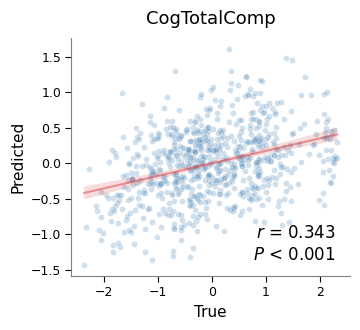

In [20]:
example_phenotypes = [
    'CogTotalComp_Unadj'
]

for behavior_name in example_phenotypes:
    plot_behavior_prediction(
        behavior_name,
        result_dir,
    )
